In [1]:
import numpy as np

class SVM(object):
    def __init__(self, eta=0.01, n_iter=1000, C=1.0, random_state=1, tol=1e-4, verbose=False):
        self.eta = eta  # Learning rate
        self.n_iter = n_iter  # Number of iterations
        self.C = C  # Regularization parameter
        self.random_state = random_state
        self.tol = tol  # Tolerance for early stopping
        self.verbose = verbose  # Print iterations
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.last_cost = None
        
        for count in range(self.n_iter):
            cost = 0
            for xi, yi in zip(X, y):
                margin = yi * (np.dot(xi, self.w_[1:]) + self.w_[0])
                
                if margin >= 1:
                    self.w_[1:] -= self.eta * self.w_[1:] 
                else:
                    self.w_[1:] -= self.eta * (self.w_[1:] - self.C * yi * xi)  
                    self.w_[0] -= self.eta * (-self.C * yi)
                
                cost += max(0, 1 - margin)  
            
            if self.last_cost is not None and abs(cost - self.last_cost) < self.tol:
                if self.verbose:
                    print(f'Uscita anticipata dopo {count} iterazioni')
                break
            self.last_cost = cost
        
        return self
    
    def predict(self, X):
        return np.where(np.dot(X, self.w_[1:]) + self.w_[0] >= 0, 1, -1)

# Classificazione di Dataset Sbilanciati con SVM

Si vuole affrontare il problema della classificazione di dataset sbilanciati, costituiti da due classi:

- classe `0` (maggioritaria),
- classe `1` (minoritaria).

Si consideri un dataset sintetico con forte sbilanciamento (ad esempio 95% dei campioni appartenenti alla classe `0` e 5% alla classe `1`).



---

## 1. Bilanciamento dei dati per training e validazione

1. Generare un dataset sintetico di classificazione binaria.

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,        # numero di campioni
    n_features=5,          # due feature per visualizzare facilmente
    n_informative=5,       # entrambe informative
    n_redundant=0,         # nessuna feature ridondante
    n_repeated=0,          # nessuna feature duplicata
    n_classes=2,           # classificazione binaria
    n_clusters_per_class=1,# un solo cluster per classe, in modo da essere linearmente separabili
    class_sep=2.0,         # maggiore separazione tra le classi
    flip_y=0.1,            # POCHISSIMO RUMORE tra le feature.
    random_state=10,
    weights=[0.9, 0.1],    # 90% classe 0, 10% classe 1
)

y = np.where(y == 0, -1, 1) # per compatibilità con nostro svm


2. Suddividere il dataset in:
   - training set,
   - test set.

3. **A partire dal training set, estrarre inizialmente un sottoinsieme bilanciato**, selezionando casualmente lo stesso numero di campioni per ciascuna classe, pari al numero di campioni della classe minoritaria.

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split

# sul campione 90/10, il 30% e' test!
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# ottieni indici delle classi nel train
idx_0 = np.where(y_train_full == -1)[0]
idx_1 = np.where(y_train_full == 1)[0]

# trova la classe minoritaria
minority_class = 1 if len(idx_1) < len(idx_0) else -1

minority_idx = np.where(y_train_full == minority_class)[0]
majority_idx = np.where(y_train_full != minority_class)[0]

# prendi solo N campioni dalla maggioritaria
np.random.seed(1)
majority_sample = np.random.choice(
    majority_idx,
    size=len(minority_idx),
    replace=False
)

# unisci
balanced_idx = np.concatenate([minority_idx, majority_sample])

# nuovo training set bilanciato
X_train_bal = X_train_full[balanced_idx]
y_train_bal = y_train_full[balanced_idx]

4. Applicare una validazione incrociata stratificata a `K` fold sul training set bilanciato ottenuto al punto precedente.
   Per praticità viene calibrato soltanto il parametro `C.`

In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# fai k fold sul training set bilanciato.
kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

# ==========================================================
# Iperparametri da testare
# ==========================================================
C_values = [0.05, 0.1, 1]

best_score = 0
best_params = None

# ==========================================================
# Loop sugli iperparametri
# ==========================================================
for C in C_values:
    fold_scores = []

    # ======================================================
    # Cross-validation
    # ======================================================
    for train_idx, val_idx in kf.split(X_train_bal, y_train_bal):

        X_train, X_val = X_train_bal[train_idx], X_train_bal[val_idx]
        y_train, y_val = y_train_bal[train_idx], y_train_bal[val_idx]

        model = SVM(eta=0.001, C=C)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        acc = np.mean(y_val==preds)

        fold_scores.append(acc)

    mean_score = np.mean(fold_scores)

    print(f"C={C} -> CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = (C,)

C=0.05 -> CV accuracy = 0.7768
C=0.1 -> CV accuracy = 0.7768
C=1 -> CV accuracy = 0.7812


Potrebbe essere utile tentare valori superiori a `1`.

In [5]:
# ==========================================================
# Migliori iperparametri
# ==========================================================
print("\nMigliori iperparametri trovati:")
print("C =", best_params[0])
print("CV accuracy media =", best_score)


Migliori iperparametri trovati:
C = 1
CV accuracy media = 0.78125


5. Al termine della cross-validation, addestrare il modello finale su un training set bilanciato (ottenuto come al punto 3) e valutarlo su un test set non bilanciato, mantenendo la distribuzione originale delle classi, al fine di ottenere una stima realistica delle prestazioni del modello in condizioni di sbilanciamento.

In [6]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVM(
    eta=0.001, # poteva valere la pena variare anche questo
    C=best_params[0],
)

final_model.fit(X_train_bal, y_train_bal)

print("\nModello finale addestrato su tutto il dataset.")



Modello finale addestrato su tutto il dataset.


6. Valutare il modello con una metrica appropriata. 

Test accuracy finale: 0.9633333333333334


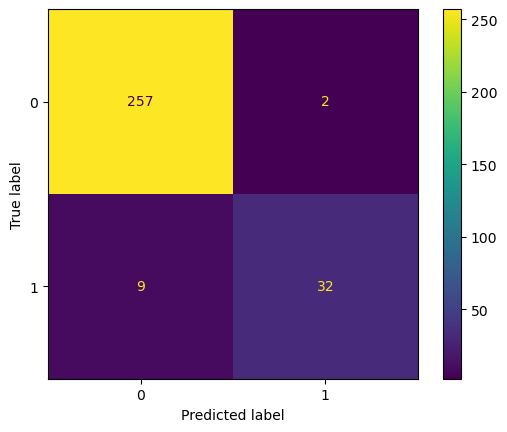


Precision: 0.9411764705882353
Recall: 0.7804878048780488


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)

print("Test accuracy finale:", test_acc)

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

# n. di positivi trovati sui veri positivi e i falsi positivi del mio modello
# se precision = 1, vuol dire che ho 0 falsi positivi
# indica quanto sono stato preciso a classificare come positivo
precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi

# n. di positivi trovati tra i positivi ed i falsi negativi
# indica quanto sono stato pre
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali ed i falsi negativi

print("\nPrecision:", precision)
print("Recall:", recall)

Dataset training molto piccolo, molta varianza. Provare con valori diversi di `random_state` nella generazione dell'instanza.


## 2. Modifica dell'implementazione della SVM


Si consideri la formulazione soft-margin della SVM:

$$
\frac{1}{2}\|w\|^2
+
C\sum_{i=1}^{N}\xi_i
$$

Modificare l'implementazione sostituendo il parametro globale `C` con un parametro specifico per ciascun campione:

$$
C_i = C \cdot v_{i}
$$

dove:

- $v_{i}$ è il peso associato alla classe del campione $i$,

I pesi di classe sono definiti come inversamente proporzionali alla frequenza delle classi nel training set:

$$
v_c = \frac{n}{2n_c}
$$

dove:

- $n$ è il numero totale di campioni del training set,
- $n_c$ è il numero di campioni appartenenti alla classe $c$.

In questo modo:

- la classe maggioritaria riceve un peso minore;
- la classe minoritaria riceve un peso maggiore;
- gli errori sui campioni della classe minoritaria vengono penalizzati maggiormente.

In [ ]:
class SVM(object):
    def __init__(self, eta=0.01, n_iter=1000, C=1.0, random_state=1, tol=1e-4, verbose=False):
        self.eta = eta  # Learning rate
        self.n_iter = n_iter  # Number of iterations
        self.C = C  # Regularization parameter
        self.random_state = random_state
        self.tol = tol  # Tolerance for early stopping
        self.verbose = verbose  # Print iterations
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.last_cost = None
        
        n0 = len(np.where(y == -1)[0])
        n1 = len(np.where(y == 1)[0])
        n = len(y)

        for count in range(self.n_iter):
            cost = 0
            for xi, yi in zip(X, y):
                margin = yi * (np.dot(xi, self.w_[1:]) + self.w_[0])
                
                if margin >= 1:
                    self.w_[1:] -= self.eta * self.w_[1:] 
                else:
                    # questa e' la modifica!
                    ni = n1 if yi == 1 else n0
                    Ci = self.C*n/(2*ni)
                    self.w_[1:] -= self.eta * (self.w_[1:] - Ci * yi * xi)  
                    self.w_[0] -= self.eta * (Ci * yi)
                
                cost += max(0, 1 - margin)  
            
            if self.last_cost is not None and abs(cost - self.last_cost) < self.tol:
                if self.verbose:
                    print(f'Uscita anticipata dopo {count} iterazioni')
                break
            self.last_cost = cost
        
        return self
    
    def predict(self, X):
        return np.where(np.dot(X, self.w_[1:]) + self.w_[0] >= 0, 1, -1)

In [9]:
kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

# ==========================================================
# Iperparametri da testare
# ==========================================================
C_values = [0.05, 0.1, 1]

best_score = 0
best_params = None

# ==========================================================
# Loop sugli iperparametri
# ==========================================================
for C in C_values:
    fold_scores = []

    # ======================================================
    # Cross-validation
    # ======================================================
    for train_idx, val_idx in kf.split(X_train_full, y_train_full):

        X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
        y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

        model = SVM(eta=0.001, C=C)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)


        acc = np.mean(y_val==preds)

        fold_scores.append(acc)

    mean_score = np.mean(fold_scores)

    print(f"C={C} -> CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = (C,)

C=0.05 -> CV accuracy = 0.9257
C=0.1 -> CV accuracy = 0.1600
C=1 -> CV accuracy = 0.8400



Modello finale addestrato su tutto il dataset.
Test accuracy finale: 0.9633333333333334


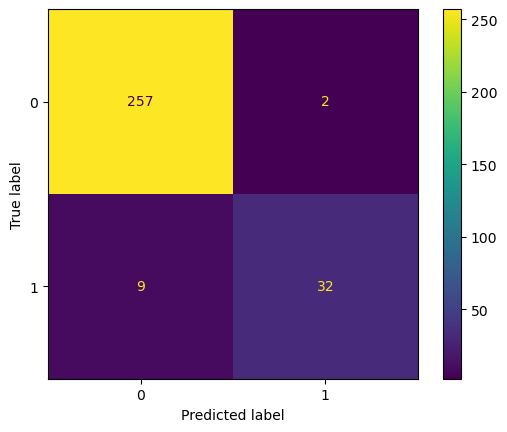


Precision: 0.9411764705882353
Recall: 0.7804878048780488


In [10]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVM(
    eta=0.001,
    C=best_params[0],
)

final_model.fit(X_train_full, y_train_full)

print("\nModello finale addestrato su tutto il dataset.")


# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)


print("Test accuracy finale:", test_acc)

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)

### Con `sklearn`

Il parametro `class_weight`: adjust weights inversely proportional to class frequencies in the input data as `n_samples / (n_classes * np.bincount(y))`.

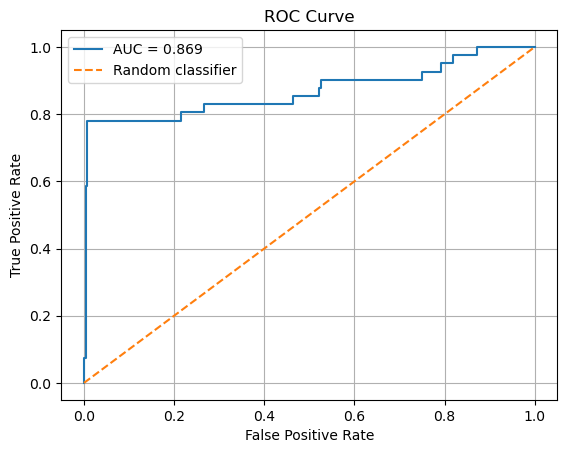

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score

model = SVC(kernel='linear', C=best_params[0], probability=True, class_weight="balanced")
model.fit(X_train_full, y_train_full)

# 4. Probabilità della classe positiva
y_scores = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# 6. Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

## Sovracampionamento (Oversampling)

Il sovracampionamento è una tecnica per aggiungere campioni alle classi minoritarie in dataset sbilanciati. Le tecniche principali sono: la *duplicazione casuale* che copia ripetutamente esempi della classe minoritaria e la *generazione sintetica* di campioni simili a quelli esistenti.

### SMOTE (Synthetic Minority Over‑sampling Technique)

**SMOTE** è una tecnica di oversampling sintetico che:

1. Per ogni campione minoritario, trova i suoi `k` vicini più prossimi.  
2. Seleziona casualmente uno di questi vicini.  
3. Genera un nuovo punto lungo il segmento che unisce i due campioni.  

In questo modo si ottengono dati più vari rispetto alla semplice duplicazione, migliorando la capacità di generalizzazione del modello.

### Bibliografia
 
[SMOTE for Imbalanced Classification](https://www.researchgate.net/publication/220543125_SMOTE_Synthetic_Minority_Over-sampling_Technique)


### Codice

### La funzione `smote`

#### Parametri di input

- **X**  
  Matrice NumPy di forma `(dataset_size, n_features)` contenente `dataset_size` esempi del training set.

- **y**  
  Vettore NumPy di forma `(dataset_size,)` con le etichette corrispondenti ai campioni di `X`.

- **lab**  
  Intero che indica l’etichetta della classe minoritaria da sovracampionare.

- **n_samples**  
  Numero intero di nuovi campioni sintetici da generare.

- **k**  
  Numero di vicini più prossimi da considerare per l’interpolazione (default = 5).

- **random_seed**  
  Seme per il generatore di numeri casuali, usata per garantire la riproducibilità (default = 0).

---

## Descrizione della funzione `smote`

1. **Impostazione del seme casuale**  
   Viene fissato il `random_seed` per rendere riproducibile la generazione dei punti sintetici.

2. **Costruzione del KD‑Tree**  
   Si costruisce un albero KD (`KDTree`) usando solo i campioni la cui etichetta è uguale a `lab`. Questo permette di trovare rapidamente i vicini più prossimi nella classe minoritaria.

3. **Selezione dei “base points”**  
   - Se il numero di esempi minoritari è ≤ `n_samples`, si utilizzano tutti come punti base.  
   - Altrimenti, si estraggono casualmente (senza ripetizione) tanti indici quanti servono per raggiungere `n_samples`.

4. **Costruzione del dizionario dei vicini**  
   Per ciascun punto base, si calcolano i suoi k‑nearest neighbours all’interno dei soli campioni minoritari e si memorizzano gli indici dei vicini in un dizionario.

5. **Generazione dei punti sintetici**  
   - Si cicla fino a ottenere `n_samples` nuovi esempi.  
   - Ad ogni iterazione, si seleziona un punto base (in modalità ciclica) e uno dei suoi vicini in modo casuale.  
   - Si estrae un fattore λ casuale ∈ [0, 1].  
   - Si crea il nuovo punto interpolando linearmente tra il punto base e il vicino scelto.

6. **Restituzione del risultato**  
   La funzione restituisce un array NumPy di forma `(n_samples, n_features)` contenente tutti i punti sintetici generati per la classe `lab`.  



In [12]:
from sklearn.neighbors import KDTree

def smote(X, y, lab, n_samples, k = 5, random_seed = 0):
    '''
    parametri: X, y matrice degli esempi ed etichette
        lab: etichetta da sovracampionare
        n_samples: numero di campioni da generare
        k: numero di vicini da usare per interpolazione
    '''
    np.random.seed(random_seed)
    
    tree = KDTree(X[ y==lab ], leaf_size=2)

    min_lab_idx =np.where(y == lab)[0] # indici dei punti X etichettati con lab
    
    # base_points_idx indici in X dei punti usati per l'intepolazione
    base_points_idx = min_lab_idx if X[ y==lab ].shape[0] <= n_samples \
        else  np.random.choice(min_lab_idx, n_samples, replace = False)
    n_base_points = base_points_idx.shape[0]

    # per ogni punto in base_points_idx calcoliamo i k-nearest neighbors e li inseriamo in un dizionario
    # con chiave l'indice, i vicini sono espressi come indici in X
    knn_dict = {}
    for i in  base_points_idx:
        knn_dict[i] = min_lab_idx[ tree.query([X[i]], k=k)[1] ] [0] # query ritorna una matrice
    
    new_points = []

    for i in range(n_samples):
        cur_base_point_idx = base_points_idx[i % n_base_points]
        xi = X[cur_base_point_idx]

        nn_idx = np.random.choice( knn_dict[cur_base_point_idx],  1)[0] # choice ritorna un array
        lmbd = np.random.rand()

        nn = X[nn_idx]
        ip = xi+lmbd*(nn-xi)
        new_points.append(ip)
    
    return np.array(new_points)

In [13]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# indici delle classi
idx_0 = np.where(y_train_full == -1)[0]
idx_1 = np.where(y_train_full == 1)[0]

# classe minoritaria (troviamo quale è più piccola)
minority_class = 1 if len(idx_1) < len(idx_0) else -1

minority_idx = np.where(y_train_full == minority_class)[0]
majority_idx = np.where(y_train_full != minority_class)[0]

new_samples = smote(X_train_full, y_train_full, minority_class, len(majority_idx)-len(minority_idx))

# nuovo training set bilanciato
X_train_bal = np.concatenate( [X_train_full, new_samples])
y_train_bal = np.concatenate( [y_train_full, np.array([minority_class]*len(new_samples))])

In [14]:
kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

# ==========================================================
# Iperparametri da testare
# ==========================================================
C_values = [0.05, 0.1, 1]

best_score = 0
best_params = None

# ==========================================================
# Loop sugli iperparametri
# ==========================================================
for C in C_values:
    fold_scores = []

    # ======================================================
    # Cross-validation
    # ======================================================
    for train_idx, val_idx in kf.split(X_train_bal, y_train_bal):

        X_train, X_val = X_train_bal[train_idx], X_train_bal[val_idx]
        y_train, y_val = y_train_bal[train_idx], y_train_bal[val_idx]

        model = SVM(eta=0.001, C=C)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)


        acc = np.mean(y_val==preds)

        fold_scores.append(acc)

    mean_score = np.mean(fold_scores)

    print(f"C={C} -> CV accuracy = {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = (C,)

C=0.05 -> CV accuracy = 0.7730
C=0.1 -> CV accuracy = 0.5000
C=1 -> CV accuracy = 0.5000



Modello finale addestrato su tutto il dataset.
Test accuracy finale: 0.96


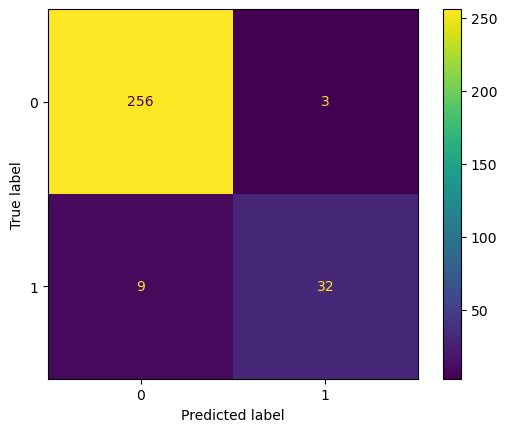


Precision: 0.9142857142857143
Recall: 0.7804878048780488
300


In [15]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVM(
    eta=0.001,
    C=best_params[0],
)

final_model.fit(X_train_bal, y_train_bal)

print("\nModello finale addestrato su tutto il dataset.")


# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)


print("Test accuracy finale:", test_acc)

cm = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)

print(len(y_test))

### Con `sklearn`

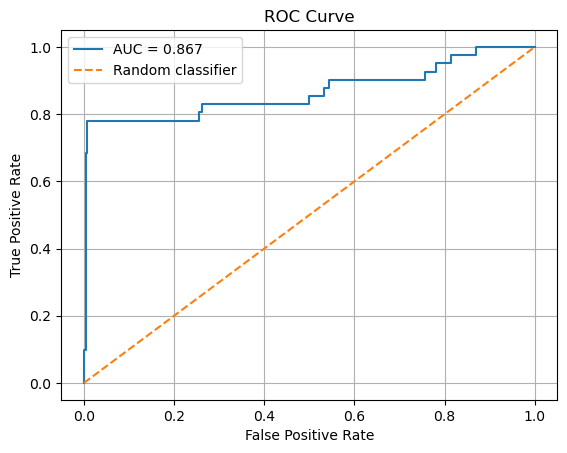

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score

model = SVC(kernel='linear', C=best_params[0], probability=True, class_weight="balanced")
model.fit(X_train_bal, y_train_bal)

# 4. Probabilità della classe positiva
y_scores = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)

# 6. Plot
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# Classificazione multiclasse con classificatore binario - One-vs-Rest (OvR)

Il problema della classificazione multiclasse può essere affrontato estendendo un classificatore binario, tramite la strategia **One-vs-Rest (OvR)**.

Si addestrano più classificatori binari indipendenti. Ogni classificatore impara a distinguere una singola classe contro tutte le altre.

Se abbiamo `k` classi, costruiamo `K` modelli:
- modello `0`: classe `0` vs resto
- modello `1`: classe `1` vs resto
- ...
- modello `K−1`: classe `K−1` vs resto

In fase di predizione, ogni modello produce uno score (p.e. distanza dal margine) e la classe finale viene scelta come quella con il punteggio più alto.

In [17]:
import numpy as np
from sklearn.svm import SVC

class OneVsRestSVM:
    def __init__(self, kernel="linear", C=1.0):
        self.kernel = kernel
        self.C = C
        self.models_ = {}

    def fit(self, X, y):
        """
        Addestra un SVM binario per ogni classe (classe vs resto).
        """
        self.classes_ = np.unique(y)

        for c in self.classes_:
            # trasformazione binaria: classe c vs resto
            y_binary = (y == c).astype(int)

            model = SVC(
                kernel=self.kernel,
                C=self.C,
            )

            model.fit(X, y_binary)
            self.models_[c] = model

        return self

    def predict(self, X):
        # matrice (n_classes, n_samples)
        scores = np.vstack([
            model.decision_function(X)
            for model in self.models_.values()
        ])

        # argmax sulle classi
        best_class_indices = np.argmax(scores, axis=0)

        return self.classes_[best_class_indices]

In [18]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# dataset 3 classi
X, y = make_classification(
    n_samples=1500,
    n_features=5,
    n_informative=5,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=1
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=1
)

model = OneVsRestSVM(kernel="rbf", C=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9844444444444445
